<a href="https://colab.research.google.com/github/WilliamDubois/glo7030-labs/blob/master/Laboratoire%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Rappel Google Colab

Tout d'abord, sélectionnez l'option GPU de Colab avec *Edit > Notebook settings* et sélectionner GPU comme Hardware accelerator.
Installer ensuite deeplib avec la commande suivante:

In [1]:
!pip install git+https://github.com/ulaval-damas/glo4030-labs.git

  Cloning https://github.com/ulaval-damas/glo4030-labs.git to /tmp/pip-req-build-2u0h0ayv
  Running command git clone --filter=blob:none --quiet https://github.com/ulaval-damas/glo4030-labs.git /tmp/pip-req-build-2u0h0ayv
  Resolved https://github.com/ulaval-damas/glo4030-labs.git to commit 1c29bfd26a9ec5a4b7349957da8b3851f8c1d073
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 63.7 MB/s eta 0:00:00
  Created wheel for deeplib: filename=deeplib-0.1-py3-none-any.whl size=10542 sha256=5794a44634988be140c8cfb1d001101c9dcdc77a28c5e4015df74690919c8dd7
  Stored in directory: /tmp/pip-ephem-wheel-cache-y_88csaf/wheels/9f/29/ed/25822e0088ad9c46b352ed51c58696b9d13fbc94e1db2ac759
Successfully built deeplib


# Laboratoire 5: CNN

Dans ce laboratoire, nous allons implémenter avec l'aide de PyTorch divers réseaux à convolutions. La [documentation de PyTorch](https://pytorch.org/docs/stable/index.html) va donc vous être d'un grand secours. Entre autres, la documentation de [`torch`](https://pytorch.org/docs/stable/torch.html), [`torch.nn`](https://pytorch.org/docs/stable/nn.html) (que nous avons importé sous le nom de `nn`) ainsi que [`torch.nn.functional`](https://pytorch.org/docs/stable/nn.functional.html) (que nous avons importé sous le nom de `F`). En particulier, voici une liste de classes ou de fonctions dont vous êtes susceptible d'utiliser au cours de ce laboratoire.
- [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
- [`nn.BatchNorm2d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d)
- [`F.max_pool2d`](https://pytorch.org/docs/stable/nn.functional.html#torch.nn.functional.max_pool2d) ou [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d)
- [`F.relu`](https://pytorch.org/docs/stable/nn.functional.html#torch.nn.functional.relu) ou [`nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU)
- [`torch.flatten`](https://pytorch.org/docs/stable/generated/torch.flatten.html#torch.flatten) ou [`nn.Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html#torch.nn.Flatten)
- [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear)
- [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html#torch.nn.Sequential)
- [`nn.ModuleList`](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html#torch.nn.ModuleList)

In [3]:


from deeplib.training import train, test
import torch.optim as optim
import torch
import numpy as np
from deeplib.datasets import load_cifar10, load_mnist
from deeplib.visualization import view_filters
import torch.nn.functional as F
import torch.nn as nn
from random import randrange

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

cifar_train, cifar_test = load_cifar10()
mnist_train, mnist_test = load_mnist()

100%|██████████| 170M/170M [00:18<00:00, 9.09MB/s]
100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


## Filtres de convolution

Lors de l'entraînement, le réseau apprend les bons paramètres à utiliser. Par contre, autrefois, il fallait utiliser des filtres faits à la main comme [les filtres de Gabor](https://en.wikipedia.org/wiki/Gabor_filter).

#### Exercice

- Le réseau suivant contient une seule couche à convolution. Créez manuellement quelques filtres que vous utiliserez pour faire de la classification sur MNIST. Par la suite, figez les poids de la couche de convolution et entraînez le réseau. Tentez d'obtenir les meilleurs résultats possibles.

In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, padding=1)
        self.fc = nn.Linear(6 * 14 * 14, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = x.flatten(1)
        x = self.fc(x)
        return x

Modifier les paramètres des filtres. Essayez de faire des filtres permettant d'extraire des caractéristiques de bas niveau (ligne, coin, etc...). Vous pouvez consulter [ceci](http://lodev.org/cgtutor/filtering.html) pour avoir des idées.

In [5]:
filters = []
filters.append([[[0, 0, 0],
                 [0, 1, 0],
                 [0, 0, 0]]]) # Ce filtre retourne l'image original

filters.append([[[1, 0, -1],
                 [1, 0, -1],
                 [1, 0, -1]]])

filters.append([[[1, 1, 1],
                 [0, 0, 0],
                 [-1, -1, -1]]])

filters.append([[[1, 1, 1],
                 [1, -8, 1],
                 [1, 1, 1]]])

filters.append([[[1, 2, 1],
                 [2, 4, 2],
                 [1, 2, 1]]])

filters.append([[[-1, -1, 0],
                 [-1, 0, 1],
                 [0, 1, 1]]])

In [6]:
# On crée le réseau, remplace les paramètres par les filtres précédents et fige les poids.

net = Net()
filters = np.asarray(filters, dtype=np.float32)
net.conv1.weight.data = torch.from_numpy(filters)
for param in net.conv1.parameters():
    param.requires_grad = False # Ceci fige chacune des couches
net = net.cuda()

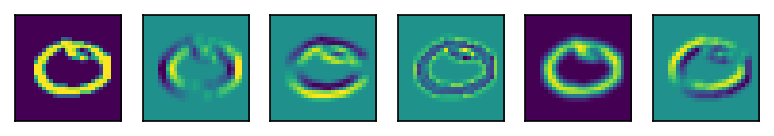

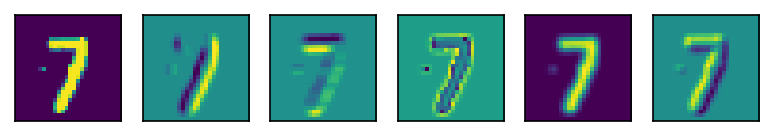

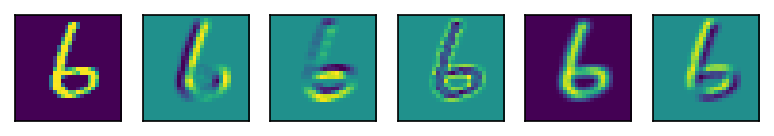

In [11]:
# Vous pouvez utiliser cette cellule pour visualiser l'effet de vos filtres sur des images du dataset.
for i in range(3):
    image, label = mnist_train[randrange(0, len(mnist_train))]
    view_filters(net, image)

In [12]:
lr = 0.001
n_epoch = 5
batch_size = 32

/usr/local/lib/python3.12/dist-packages/poutyne/framework/metrics/decomposable.py:59: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  values = [float(output)]


Epoch: 1/5 Train steps: 1500 Val steps: 375 11.20s loss: 0.267266 acc: 92.212500 val_loss: 0.186001 val_acc: 94.275000
Epoch: 2/5 Train steps: 1500 Val steps: 375 9.41s loss: 0.149541 acc: 95.666667 val_loss: 0.129816 val_acc: 96.166667
Epoch: 3/5 Train steps: 1500 Val steps: 375 9.83s loss: 0.123167 acc: 96.370833 val_loss: 0.124902 val_acc: 96.266667
Epoch: 4/5 Train steps: 1500 Val steps: 375 9.83s loss: 0.110966 acc: 96.614583 val_loss: 0.130212 val_acc: 95.808333
Epoch: 5/5 Train steps: 1500 Val steps: 375 9.79s loss: 0.099529 acc: 97.018750 val_loss: 0.120248 val_acc: 96.458333


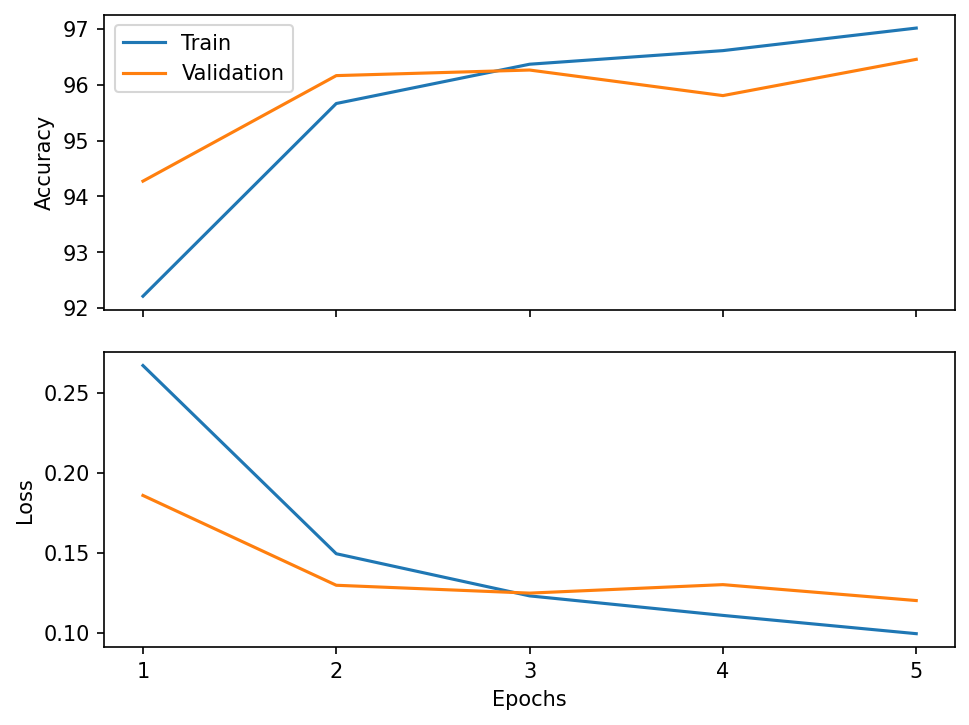

Test steps: 313 1.98s test_loss: 0.113747 test_acc: 96.550000                                 
Précision en test: 96.55


In [13]:
optimizer = optim.Adam(net.fc.parameters(), lr=lr) # On optimise uniquement la couche pleinement connectée.
history = train(net, optimizer, mnist_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(net, mnist_test, batch_size)))

Entraînons maintenant le même réseau mais cette fois-ci, laissez l'optimiseur Adam faire son travail d'optimiser les couches à convolutions. Nous pourrons en même temps comparer si nos filtres faits à la main compétitionne avec les filtres entraînés. Remarquez cependant qu'ici, nous entraînons seulement avec 6 filtres et 1 seule couche alors qu'il est possible d'entraîner un réseau avec des milliers de filtres et plusieurs dizaines de couches.

Epoch: 1/5 Train steps: 1500 Val steps: 375 10.31s loss: 0.418382 acc: 88.214583 val_loss: 0.291362 val_acc: 91.058333
Epoch: 2/5 Train steps: 1500 Val steps: 375 9.65s loss: 0.246103 acc: 92.862500 val_loss: 0.211226 val_acc: 93.883333
Epoch: 3/5 Train steps: 1500 Val steps: 375 10.14s loss: 0.181767 acc: 94.768750 val_loss: 0.159658 val_acc: 95.250000
Epoch: 4/5 Train steps: 1500 Val steps: 375 10.16s loss: 0.139634 acc: 95.964583 val_loss: 0.133760 val_acc: 96.108333
Epoch: 5/5 Train steps: 1500 Val steps: 375 10.26s loss: 0.114024 acc: 96.695833 val_loss: 0.112613 val_acc: 96.833333


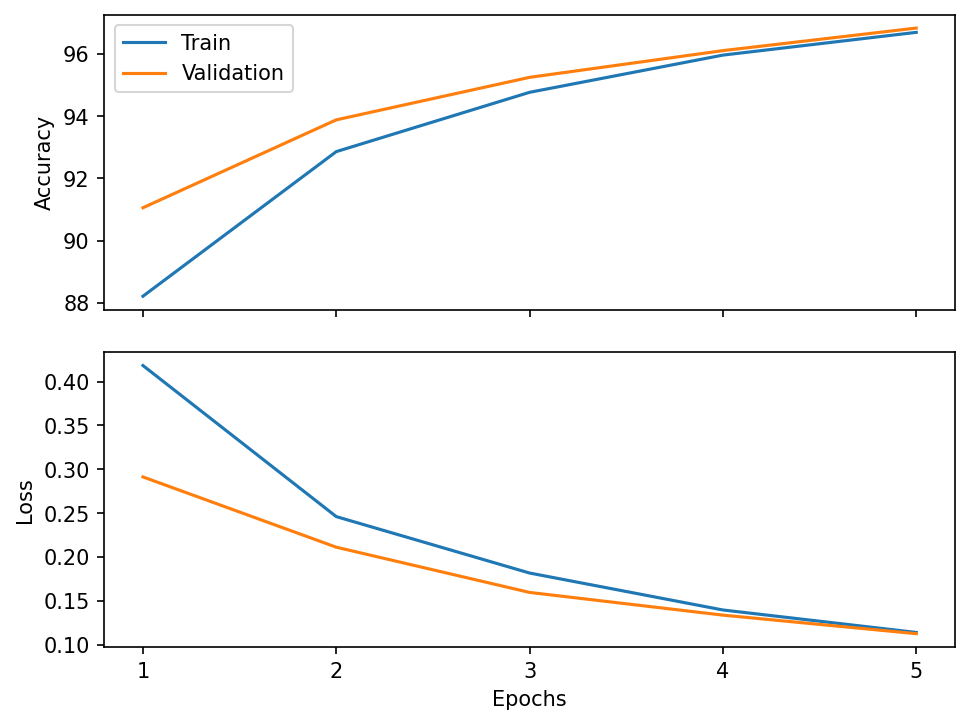

Test steps: 313 1.31s test_loss: 0.097596 test_acc: 97.000000                                  
Précision en test: 97.00


In [14]:
net = Net()
net.cuda()

# On optimise autant la couche à convolution que la couche de classification.
optimizer = optim.Adam(net.parameters(), lr=lr)

history = train(net, optimizer, mnist_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(net, mnist_test, batch_size)))

Visualisons les filtres qui ont été appris par le réseau.

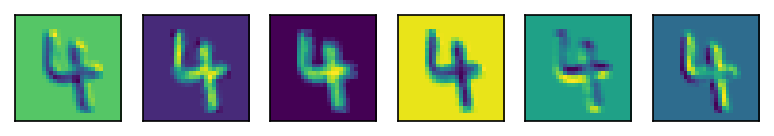

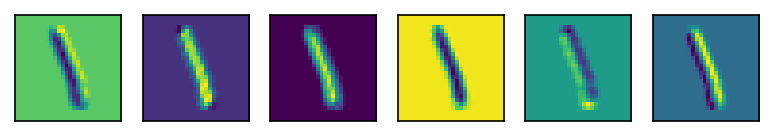

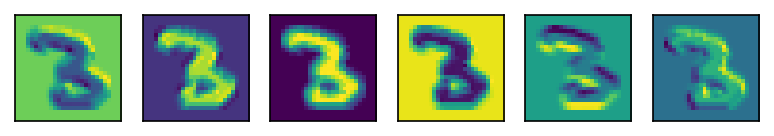

In [15]:
for i in range(3):
    image, label = mnist_train[randrange(0, len(mnist_train))]
    view_filters(net, image)

## Utilisation des filtres à convolutions

Comme on peut le constater dans l'interface de la classe [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d) de PyTorch, les couches à convolutions ont des hyperparamètres ayant tous divers effets. Dans cette section, nous explorerons les plus importants.

Voici donc l'interface simplifiée de la classe:

`nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)`

Lorsqu'on utilise la classe, elle s'attend à recevoir en entrée un tenseur de taille `(taille de la batch, canaux, hauteur, largeur)`. Par exemple dans le cas de CIFAR10, on aurait en tenseur de taille `(taille de la batch, 3, 32, 32)`. Créons-nous un tenseur de taille similaire avec une taille de batch de 8 afin de tester la classe `nn.Conv2d` de PyTorch.

In [17]:
image_batch = torch.randn(8, 3, 32, 32)

Notez que le premier paramètre `in_channels` de `nn.Conv2d` doit correspondre au nombre de canaux (*channels*) du tenseur donné en entrée de la couche. Par exemple, la couche à convolution de 100 filtres 3x3 que l'on crée dans **le code suivant va nous donner une erreur** étant donné qu'on spécifie 2 canaux au lieu de 3.

In [18]:
conv = nn.Conv2d(2, 100, 3)
conv(image_batch)

RuntimeError: Given groups=1, weight of size [100, 2, 3, 3], expected input[8, 3, 32, 32] to have 2 channels, but got 3 channels instead

Créons maintenant une couche à convolution de 100 filtres 3x3 avec le bon nombre de canaux en entrée et regardons la shape du tenseur résultant.

In [19]:
conv = nn.Conv2d(3, 100, 3)
conv(image_batch).shape

torch.Size([8, 100, 30, 30])

On remarque que la taille du tenseur de sortie a 100 canaux étant donné qu'on a demandé 100 filtres à convolution. On remarque aussi que la hauteur et la largeur ont diminué de 2 dû à la convolution. Pour pallier à ceci, ajoutons un padding de 1.

In [20]:
conv = nn.Conv2d(3, 100, 3, padding=1)
conv(image_batch).shape

torch.Size([8, 100, 32, 32])

#### Exercice

- Quand vient le temps d'empiler les couches à convolution, il faut tenir compte du nombre de canaux en sortie de la couche précédente pour la couche suivante. Corrigez le code ci-dessous pour que l'appel des couches à convolution s'effectue sans erreur. (changer le in dimension de conv2 de 64 à 32)

In [22]:
# TODO Corrigez le code suivant
conv1 = nn.Conv2d(3, 32, 3, padding=1)
conv2 = nn.Conv2d(32, 100, 3, padding=1)
conv2(conv1(image_batch)).shape

torch.Size([8, 100, 32, 32])

#### Exercice

- Testons maintenant avec des filtres de tailles différentes. On remarquera que la hauteur et la largeur ont changé avec des filtres plus gros. Ajustez le padding pour que la hauteur et la largeur restent les mêmes, c'est-à-dire 32x32.

In [24]:
conv = nn.Conv2d(3, 100, 5, padding=2)
print("Filtre 5x5:", conv(image_batch).shape)

conv = nn.Conv2d(3, 100, 7, padding=3)
print("Filtre 7x7:", conv(image_batch).shape)

Filtre 5x5: torch.Size([8, 100, 32, 32])
Filtre 7x7: torch.Size([8, 100, 32, 32])


Mettons maintenant un *stride* de 2. Ceci va faire en sorte que les filtres à convolutions auront des déplacements de taille 2 au lieu de 1.

In [25]:
conv = nn.Conv2d(3, 100, 3, padding=1, stride=2)
conv(image_batch).shape

torch.Size([8, 100, 16, 16])

On remarque que la hauteur et la largeur du tenseur résultant ont été divisées par 2.

## Architecture de base

#### Exercice

- Implémentez une architecture de base de réseau de neurones à convolution pour CIFAR10 ayant les caractéristiques suivantes.

    1. 3 couches à convolution (voir [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)).
    2. Toutes les couches ont 100 filtres de taille 3x3 et 1 de padding.
    3. Batch normalization après chaque couche (voir [`nn.BatchNorm2d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d)).
    4. Utiliser la ReLU comme fonction d'activation (Voir [`F.relu`](https://pytorch.org/docs/stable/nn.functional.html#torch.nn.functional.relu) ou [`nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU)).
    5. Maxpooling avec un noyau de taille 2 après les 2 premières couches. (Voir [`F.max_pool2d`](https://pytorch.org/docs/stable/nn.functional.html#torch.nn.functional.max_pool2d) ou [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d)).
    6. 1 seule couche linéaire pour la classification (aucune activation nécessaire) (Voir [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear)).

Ne pas oublier d'utiliser [`torch.flatten`](https://pytorch.org/docs/stable/generated/torch.flatten.html#torch.flatten) ou [`nn.Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html#torch.nn.Flatten) avant la couche de classification sinon vous allez obtenir des erreurs de *shape*.

Essentiellement, chaque couche devrait consister en `Conv2d -> BatchNorm2d -> ReLU` suivi de `MaxPool2d` pour les deux premières couches. Notez que le maxpooling et la ReLU pourraient être échangés étant donné que tous les deux sont des opérations de maximum. Pour vous faciliter les prochains exercices, on vous demande de suivre l'ordre donné ici.

Notez que la taille des images de CIFAR10 est de 3x32x32 (images en couleur). Il faut donc tenir en compte de cela lors de l'instanciation de la première couche à convolutions.

In [47]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 100, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(100)
        self.conv2 = nn.Conv2d(100, 100, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(100)
        self.conv3 = nn.Conv2d(100, 100, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(100)
        self.fc = nn.Linear(100 * 8 * 8, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

In [48]:
lr = 0.001
n_epoch = 5
batch_size = 32

Epoch: 1/5 Train steps: 1250 Val steps: 313 13.73s loss: 1.235319 acc: 57.135000 val_loss: 0.995467 val_acc: 65.450000
Epoch: 2/5 Train steps: 1250 Val steps: 313 13.94s loss: 0.819251 acc: 71.657500 val_loss: 1.200622 val_acc: 60.280000
Epoch: 3/5 Train steps: 1250 Val steps: 313 13.41s loss: 0.671098 acc: 76.782500 val_loss: 1.020106 val_acc: 66.350000
Epoch: 4/5 Train steps: 1250 Val steps: 313 13.49s loss: 0.560936 acc: 80.505000 val_loss: 0.737465 val_acc: 75.270000
Epoch: 5/5 Train steps: 1250 Val steps: 313 13.42s loss: 0.470201 acc: 83.657500 val_loss: 0.810260 val_acc: 73.970000


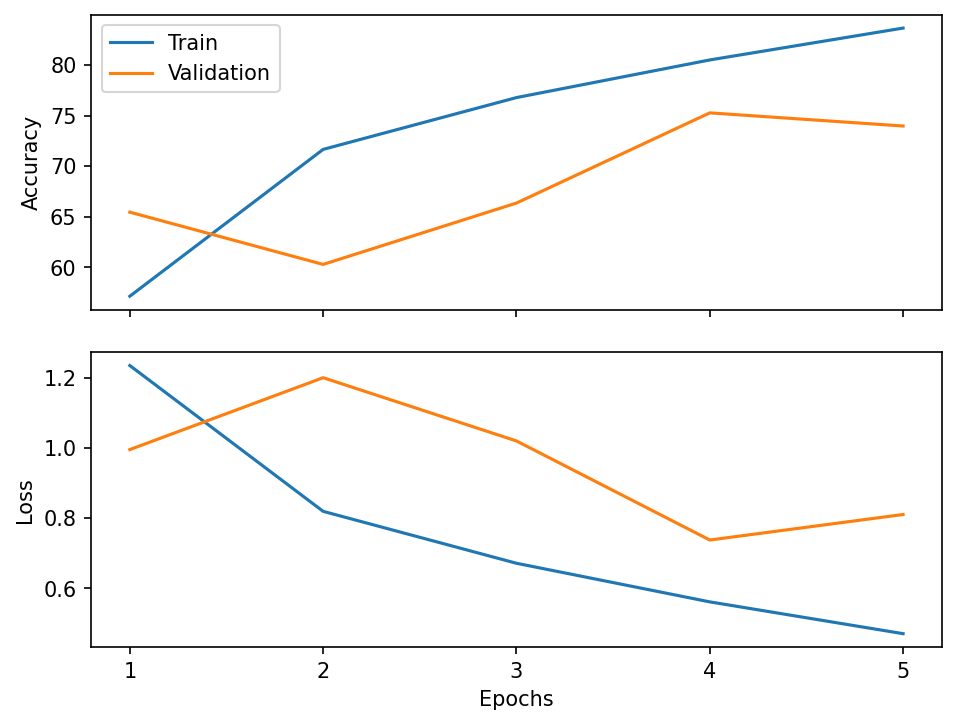

Test steps: 313 2.37s test_loss: 0.817315 test_acc: 73.090000                                 
Précision en test: 73.09


In [49]:
model = ConvNet()
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))

## Architecture profonde

#### Exercice

- Ajoutez 2 couches de convolution de 100 filtres dans le réseau précédent (n'oubliez pas la batch normalization et le padding). Mettez du maxpooling après la couche 1 et 3. Comparez les résultats.

In [50]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 100, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(100)
        self.conv2 = nn.Conv2d(100, 100, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(100)
        self.conv3 = nn.Conv2d(100, 100, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(100)
        self.conv4 = nn.Conv2d(100, 100, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(100)
        self.conv5 = nn.Conv2d(100, 100, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(100)
        self.fc = nn.Linear(100 * 8 * 8, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

Epoch: 1/5 Train steps: 1250 Val steps: 313 17.51s loss: 1.310360 acc: 53.855000 val_loss: 0.983772 val_acc: 65.600000
Epoch: 2/5 Train steps: 1250 Val steps: 313 16.70s loss: 0.820012 acc: 71.465000 val_loss: 0.859673 val_acc: 70.100000
Epoch: 3/5 Train steps: 1250 Val steps: 313 16.81s loss: 0.640902 acc: 77.560000 val_loss: 0.708609 val_acc: 75.600000
Epoch: 4/5 Train steps: 1250 Val steps: 313 16.77s loss: 0.514911 acc: 82.170000 val_loss: 0.768451 val_acc: 74.450000
Epoch: 5/5 Train steps: 1250 Val steps: 313 16.32s loss: 0.413964 acc: 85.590000 val_loss: 0.646825 val_acc: 78.380000


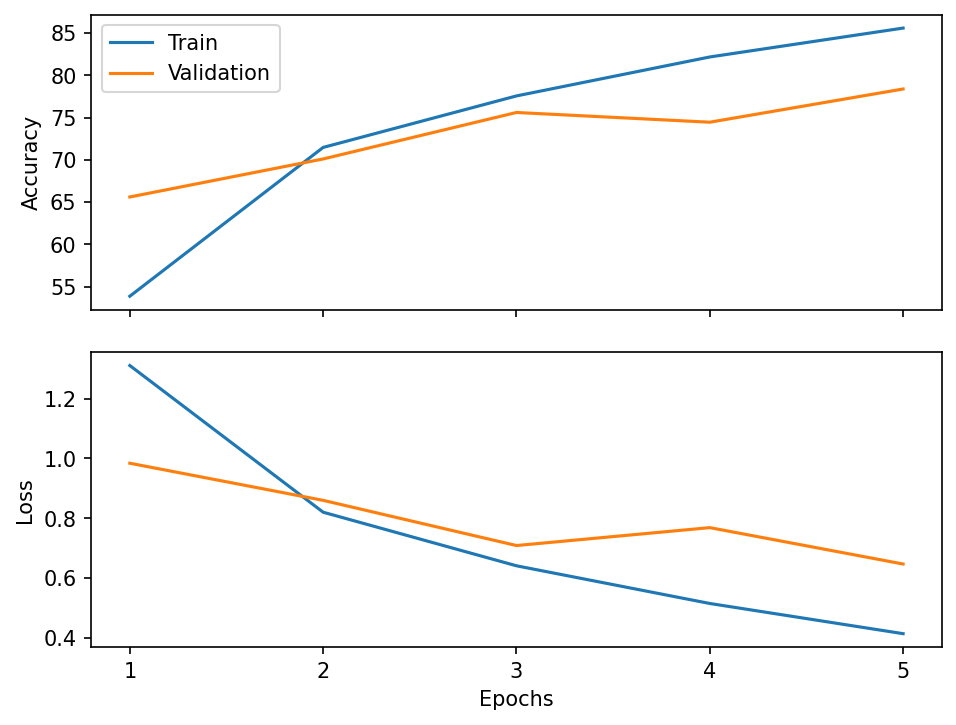

Test steps: 313 1.92s test_loss: 0.657788 test_acc: 78.340000                                 
Précision en test: 78.34


In [51]:
model = ConvNet()
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))

#### Question
- Que remarquez-vous par rapport au performance du réseau précédent?
Le réseau semble plus performant.

#### Exercice

- Codez le réseau ci-dessous qui prend en paramètre le nombre de couches désiré. Vous allez devoir utiliser la classe [`nn.ModuleList`](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html#torch.nn.ModuleList) pour pouvoir avoir un nombre variable de couches. Encore une fois, chaque couche va consister en 100 filtres à convolution 3x3 avec padding de 1 suivi d'une batch normalization et d'une ReLU. Mettez du maxpooling après les couches 3 et 5. Vous pouvez supposer que le nombres de couche demandé est plus de 5. Entrainez ensuite le réseau avec 51 couches.

    L'entraînement risque de prendre un certain temps. Vous avez certainement le temps d'aller prendre un bon café.

In [52]:
class ConvNet(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        assert num_layers > 5
        self.num_layers = num_layers
        self.conv1 = nn.Conv2d(3, 100, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(100)

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers - 2):
            self.convs.append(nn.Conv2d(100,100,3,padding=1))
            self.bns.append(nn.BatchNorm2d(100))

        self.fc = nn.Linear(100 * 8 * 8, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        for i, conv, bn in zip(range(2, self.num_layers + 2), self.convs, self.bns):
            x = F.relu(bn(conv(x)))
            if i in [3, 5]:
                x = F.max_pool2d(x, 2)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

Epoch: 1/5 Train steps: 1250 Val steps: 313 1m22.82s loss: 2.261199 acc: 13.320000 val_loss: 2.134400 val_acc: 17.130000
Epoch: 2/5 Train steps: 1250 Val steps: 313 1m18.28s loss: 2.192169 acc: 15.290000 val_loss: 1.986239 val_acc: 19.390000
Epoch: 3/5 Train steps: 1250 Val steps: 313 1m18.74s loss: 1.899572 acc: 24.225000 val_loss: 1.868011 val_acc: 25.930000
Epoch: 4/5 Train steps: 1250 Val steps: 313 1m18.61s loss: 1.943021 acc: 24.792500 val_loss: 2.097703 val_acc: 16.350000
Epoch: 5/5 Train steps: 1250 Val steps: 313 1m18.73s loss: 2.086994 acc: 18.100000 val_loss: 2.219898 val_acc: 16.230000


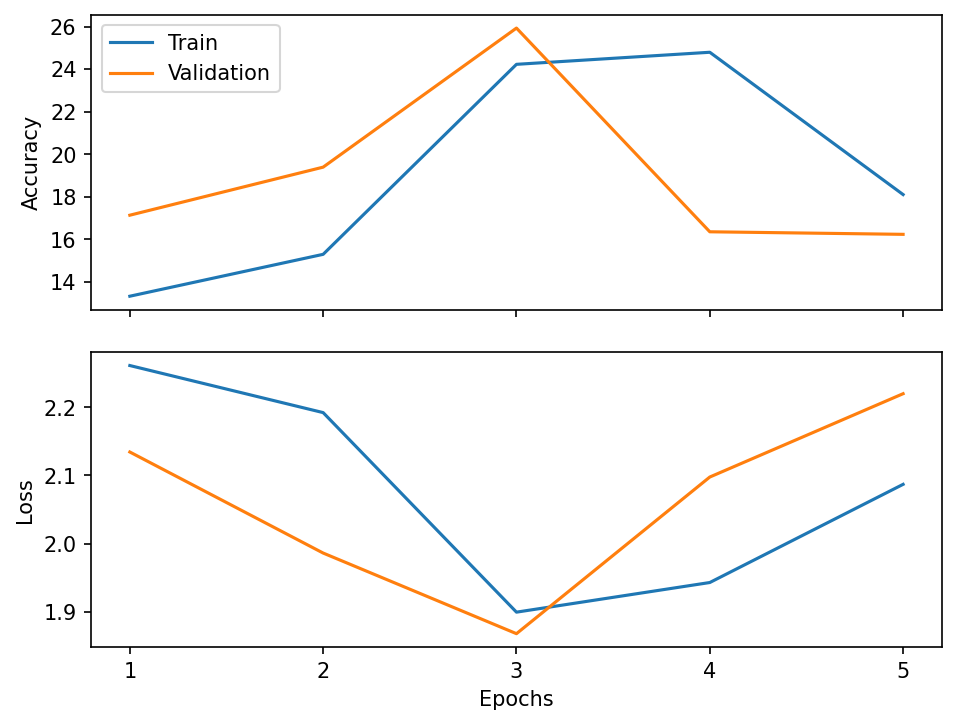

Test steps: 313 3.70s test_loss: 2.215351 test_acc: 16.780000                                 
Précision en test: 16.78


In [53]:
model = ConvNet(51)
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))

#### Question

- Que remarquez-vous par rapport au performance du réseau précédent?

La performance est shit, il y a trop de couches pour apprendre quoi que ce soit.

### Un petit défi (exercice facultatif)

PyTorch fournit l'interface de programmation [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html#torch.nn.Sequential) permettant de programmer et de visualiser plus facilement les réseaux programmables sous forme de couches. Au lieu d'hériter de la classe [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module), on instancie un objet `nn.Sequential` avec les couches désirés en paramètre. L'objet `nn.Sequential` se chargera d'appeler dans l'ordre fourni chaque couche avec en entrée la sortie de la couche précédente.

Prenons l'exemple ci-dessous qui contient seulement une couche à convolutions, quelques activations et une couche linéaire.

In [54]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 100, 3, padding=1)
        self.fc = nn.Linear(100 * 16 * 16, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = x.flatten(1)
        x = self.fc(x)
        return x

net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=25600, out_features=10, bias=True)
)


En utilisant l'interface `nn.Sequential`, On peut simplifier le code comme ci-dessous. On remarquera également qu'avec l'affichage d'un réseau utilisant `nn.Sequential`, les opérations exécutées par le réseau sont beaucoup clairs et explicites qu'avec `nn.Module`.

In [55]:
def create_sequential_network():
    return nn.Sequential(
        nn.Conv2d(3, 100, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(100 * 16 * 16, 10)
    )

net = create_sequential_network()
print(net)

Sequential(
  (0): Conv2d(3, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=25600, out_features=10, bias=True)
)


On vous soumet donc ici un défi. Le but est de réimplémenter le réseau que l'on vient de coder en utilisant l'interface `nn.Sequential`.

In [70]:
def create_sequential_conv_net(num_layers):
    assert num_layers > 5
    layers = []
    layers.append(nn.Conv2d(3,100,3,padding=1))
    layers.append(nn.BatchNorm2d(100))
    layers.append(nn.ReLU())

    # TODO Ajoutez les couches à la liste "layers" ici.
    for i in range(2, num_layers+1):
      layers.append(nn.Conv2d(100,100,3,padding=1))
      layers.append(nn.BatchNorm2d(100))
      layers.append(nn.ReLU())
      if i in [3,5]:
        layers.append(nn.MaxPool2d(2))
    layers.append(nn.Flatten())
    layers.append(nn.Linear(100*8*8, 10))
    return nn.Sequential(*layers)

Il n'est pas nécessaire d'effectuer l'entraînement au complet, juste de confirmer que votre implémentation a des performances similaires à votre implémentation précédente.

Epoch: 1/5 Train steps: 1250 Val steps: 313 1m22.46s loss: 2.311707 acc: 10.945000 val_loss: 2.263111 val_acc: 13.160000
Epoch: 2/5 Train steps: 1250 Val steps: 313 1m20.07s loss: 2.253987 acc: 13.095000 val_loss: 2.248935 val_acc: 15.130000
Epoch: 3/5 Train steps: 1250 Val steps: 313 1m19.68s loss: 2.091567 acc: 17.977500 val_loss: 2.023869 val_acc: 18.750000
Epoch: 4/5 Train steps: 1250 Val steps: 313 1m20.41s loss: 1.903874 acc: 24.122500 val_loss: 1.899448 val_acc: 26.240000
Epoch: 5/5 Train steps: 1250 Val steps: 313 1m19.81s loss: 1.752369 acc: 30.522500 val_loss: 1.762355 val_acc: 31.240000


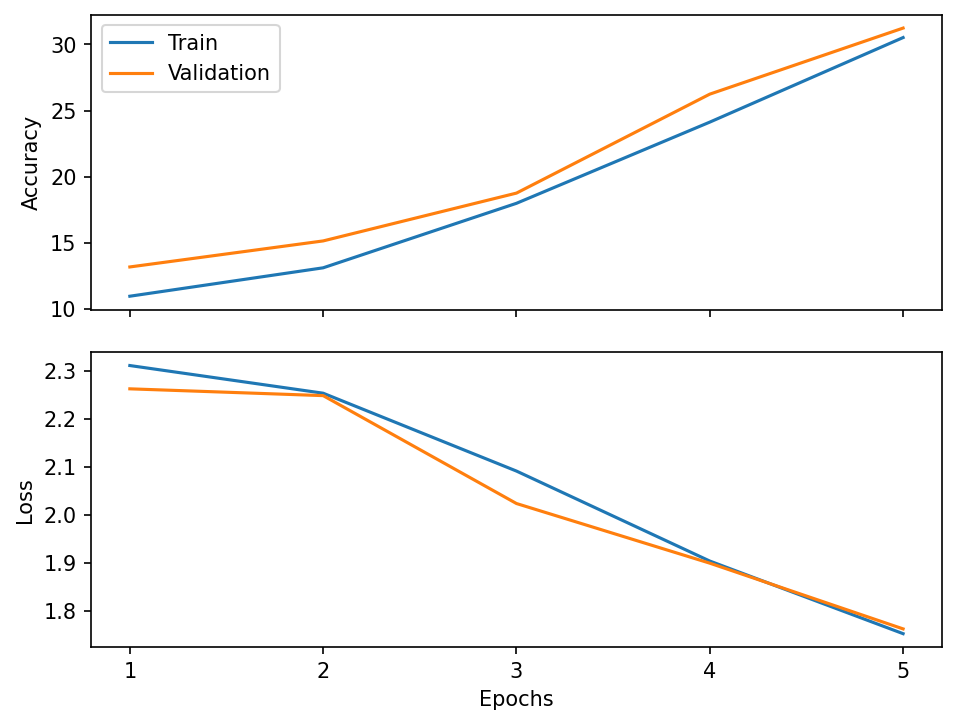

Test steps: 313 4.36s test_loss: 1.753732 test_acc: 31.410000                                 
Précision en test: 31.41


In [71]:
model = create_sequential_conv_net(51)
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))

## Connexion résiduelle

Comme vous avez pu le constater, ajouter de plus en plus de couches augmente aussi la difficulté avec laquelle le gradient peut se propager dans le réseau. Une des solutions suggérées est d'utiliser une connexion résiduelle permettant au gradient de _sauter_ des couches. Dans l'article présentant cette connexion, elle est définie comme suit:

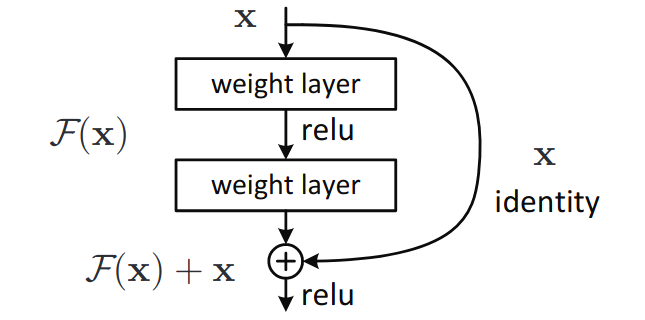

#### Exercice

- Implémentez cette connexion sous une forme de couche dans la classe `ResidualLayer` ci-dessous. Vous pouvez la tester avec le réseau `ShallowResnet` fourni ci-bas. Dans notre cas, chaque *weight layer* consiste en une couche à convolution à 100 filtres 3x3 avec padding de 1 suivi d'une batch normalization. Prenez pour acquis que le nombre de *canaux* en entrée de votre couche sera de 100.

In [72]:
class ResidualLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight1 = nn.Conv2d(100, 100, 3, padding=1)
        self.weight2 = nn.Conv2d(100, 100, 3, padding=1)

    def forward(self, x):
        x_w1 = F.relu(self.weight1(x))
        x_w2 = F.relu(self.weight2(x_w1))
        out = F.relu(x_w2 + x)
        return out

Testez votre implémentation de votre couche résiduelle avec le réseau peu profond ci-dessous.

In [73]:
class ShallowResnet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 100, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(100)

        self.res1 = ResidualLayer()
        self.res2 = ResidualLayer()
        self.res3 = ResidualLayer()

        self.fc1 = nn.Linear(100 * 8 * 8, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.res1(x)
        x = F.max_pool2d(x, 2)
        x = self.res2(x)
        x = F.max_pool2d(x, 2)
        x = self.res3(x)
        x = x.flatten(1)
        x = self.fc1(x)
        return x

Il n'est pas nécessaire d'effectuer l'entraînement au complet, juste de confirmer que votre implémentation a des "bonnes" performances.

Epoch: 1/5 Train steps: 1250 Val steps: 313 43.03s loss: 1.633603 acc: 47.645000 val_loss: 1.278769 val_acc: 55.510000
Epoch: 2/5 Train steps: 1250 Val steps: 313 40.75s loss: 1.168094 acc: 60.057500 val_loss: 1.190257 val_acc: 59.220000
Epoch: 3/5 Train steps: 1250 Val steps: 313 41.07s loss: 1.045804 acc: 64.105000 val_loss: 1.049560 val_acc: 64.040000
Epoch: 4/5 Train steps: 1250 Val steps: 313 39.94s loss: 0.976833 acc: 66.550000 val_loss: 1.110502 val_acc: 62.700000
Epoch: 5/5 Train steps: 1250 Val steps: 313 40.09s loss: 0.916221 acc: 68.677500 val_loss: 1.044792 val_acc: 65.230000


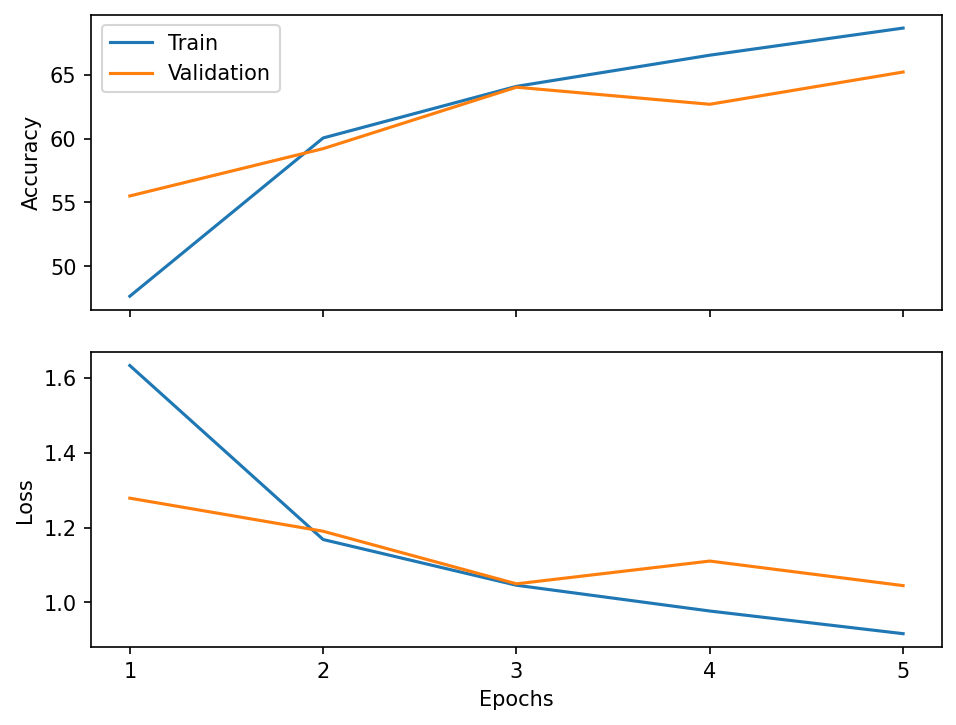

Test steps: 313 2.87s test_loss: 1.028761 test_acc: 65.660000                                 
Précision en test: 65.66


In [74]:
model = ShallowResnet()
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))

#### Exercice

- Codez le réseau à connexion résiduelle ci-dessous qui prend en paramètre le nombre de couches résiduelles désiré. Encore une fois, vous allez devoir utiliser la classe [`nn.ModuleList`](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html#torch.nn.ModuleList) ou [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html#torch.nn.Sequential) pour pouvoir avoir un nombre variable de couches. Notez qu'ici `num_layers` représente le nombre de couches résiduelles et non le nombre de couches à convolution. Le réseau devrait consister d'une couche `Conv2d -> BatchNorm2d -> ReLU` suivi de `num_layers` couches résiduelles et terminer par la couche de classification. Faites un maxpool après les couches résiduelles 1 et 2.

    Entrainez le réseau avec 25 couches résiduelles (donc au total 51 couches à convolution si compte la première couche non résiduelle).

In [75]:
class Resnet(nn.Module):
    def __init__(self, num_layers):
        super(Resnet, self).__init__()
        assert num_layers > 5
        self.num_layers = num_layers
        self.conv1 = nn.Conv2d(3, 100, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(100)

        self.res_layers = []
        for i in range(num_layers):
          self.res_layers.append(ResidualLayer())
        self.fc = nn.Linear(100*8*8, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        for i, res_layer in zip(range(1, self.num_layers+1), self.res_layers):
          x = res_layer(x)
          if i in [1,2]:
            x = F.max_pool2d(x)
        x = x.flatten()
        x = self.fc(x)
        return x


In [76]:
model = Resnet(25)
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

#### Question

- Comparez les résultats et la vitesse avec laquelle le réseau a entraîné par rapport au réseau à convolution de 51 couches entrainé plus haut.

#### Exercice facultatif

- Comme le défi lancé précédemment, tentez d'implémenter le réseau à connexion résiduelle en n'utilisant que l'interface `nn.Sequential`. Vous pouvez utiliser la couche `ResidualLayer` définie précédemment.

In [ ]:
def create_sequential_resnet(num_layers):
    assert num_layers > 2
    layers = []

    # TODO Ajoutez les couches à la liste "layers" ici.

    return nn.Sequential(*layers)

Il n'est pas nécessaire d'effectuer l'entraînement au complet, juste de confirmer que votre implémentation a des performances similaires à votre implémentation précédente.

In [ ]:
model = create_sequential_resnet(25)
model.cuda()

optimizer = optim.Adam(model.parameters(), lr=lr)
history = train(model, optimizer, cifar_train, n_epoch, batch_size)
history.display()
print('Précision en test: {:.2f}'.format(test(model, cifar_test, batch_size)))